In [1]:
!pip install yfinance statsmodels

import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

In [2]:
ticker = "CONCOR.NS"
df = yf.download(ticker, period="1y")

df = df[['Close']]
df.reset_index(inplace=True)

df.head()

/tmp/ipykernel_13982/25074557.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1y")
[*********************100%***********************]  1 of 1 completed


Price,Date,Close
Ticker,,CONCOR.NS
0,2025-04-21,559.543640
1,2025-04-22,558.403442
2,2025-04-23,561.037659
3,2025-04-24,556.476685
4,2025-04-25,533.750610


In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [4]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_13982/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


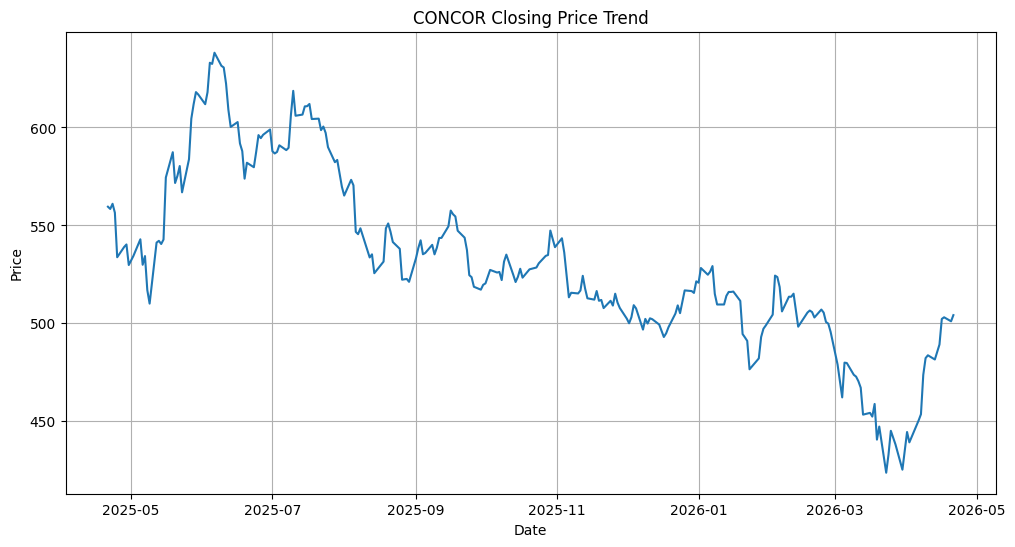

In [5]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'])
plt.title("CONCOR Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid()
plt.show()

In [6]:
result = adfuller(df['Close'])
print("ADF p-value:", result[1])

ADF p-value: 0.48198096397136286


In [7]:
df_diff = df.diff().dropna()

result = adfuller(df_diff['Close'])
print("New p-value:", result[1])

New p-value: 5.83446026123333e-09


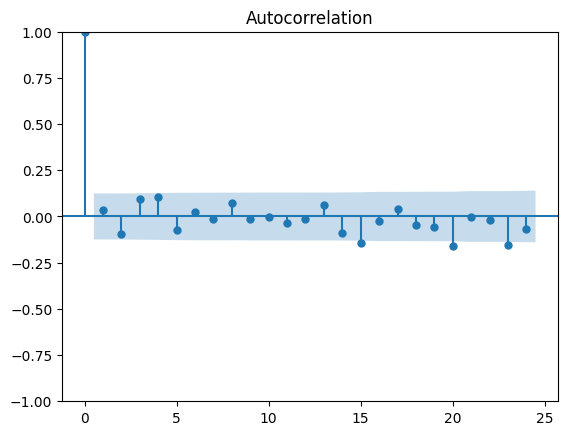

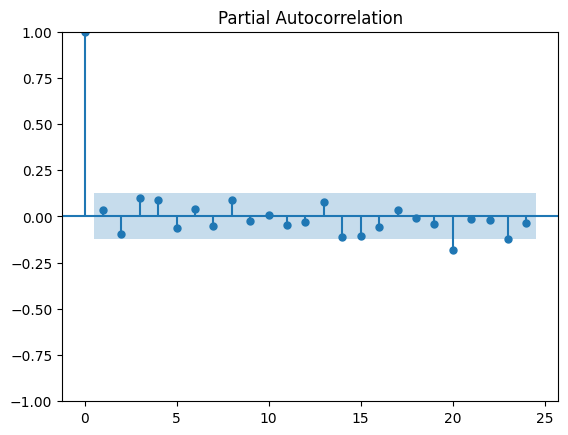

In [8]:
plot_acf(df_diff['Close'])
plot_pacf(df_diff['Close'])
plt.show()

In [9]:
model = ARIMA(df['Close'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

                               SARIMAX Results                                
Dep. Variable:              CONCOR.NS   No. Observations:                  249
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -875.649
Date:                Tue, 21 Apr 2026   AIC                           1757.299
Time:                        15:59:01   BIC                           1767.839
Sample:                             0   HQIC                          1761.542
                                - 249                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4409      0.551     -0.800      0.424      -1.521       0.639
ma.L1          0.5096      0.516      0.988      0.323      -0.502       1.521
sigma2        68.2909      4.519     15.112      0.0

In [10]:
forecast = model_fit.forecast(steps=30)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


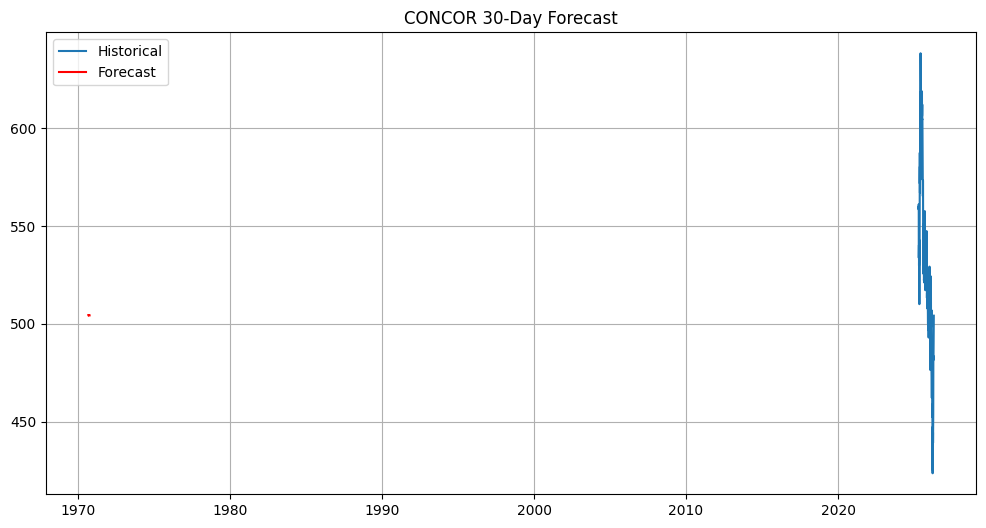

In [11]:
plt.figure(figsize=(12,6))

plt.plot(df['Close'], label='Historical')
plt.plot(forecast, label='Forecast', color='red')

plt.legend()
plt.grid()
plt.title("CONCOR 30-Day Forecast")

plt.show()